In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("OpenCV version:", cv2.__version__)
print("Library berhasil di-import.")

OpenCV version: 4.14.0
Library berhasil di-import.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 01_HighQuality_Enhanced_NOTTD.jpg to 01_HighQuality_Enhanced_NOTTD.jpg


In [ ]:
nama_file = "01_HighQuality_Enhanced_CROP2.jpg"

img = cv2.imread(nama_file)

if img is None:
    print("ERROR: File tidak ditemukan!")
else:
    print("File berhasil dibaca:", nama_file)
    print("Ukuran gambar:", img.shape)

File berhasil dibaca: 01_HighQuality_Enhanced_CROP2.jpg
Ukuran gambar: (362, 837, 3)


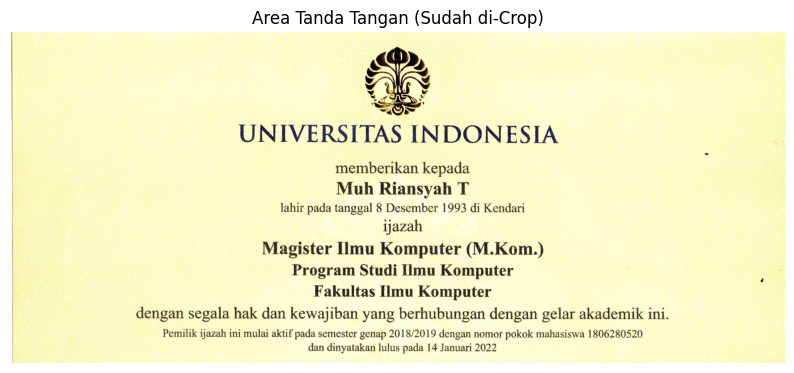

In [ ]:
# Karena gambar sudah di-crop,
# gambar langsung dianggap sebagai ROI tanda tangan

roi = img.copy()

roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.imshow(roi_rgb)
plt.title("Area Tanda Tangan (Sudah di-Crop)")
plt.axis("off")
plt.show()

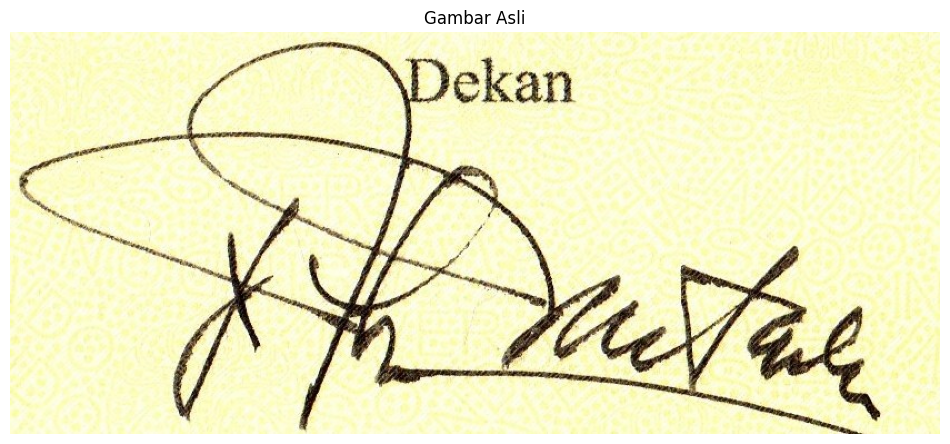

In [ ]:
# Konversi BGR -> RGB untuk matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()

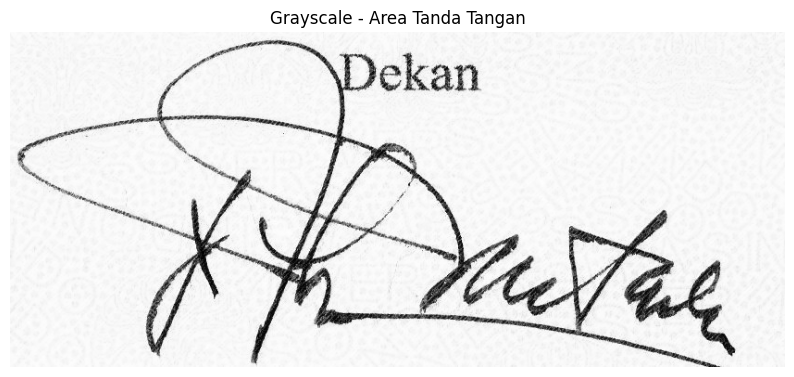

Ukuran grayscale: (362, 837)


In [ ]:
# ==========================================
# GRAYSCALE
# ==========================================

gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale - Area Tanda Tangan")
plt.axis("off")
plt.show()

print("Ukuran grayscale:", gray.shape)

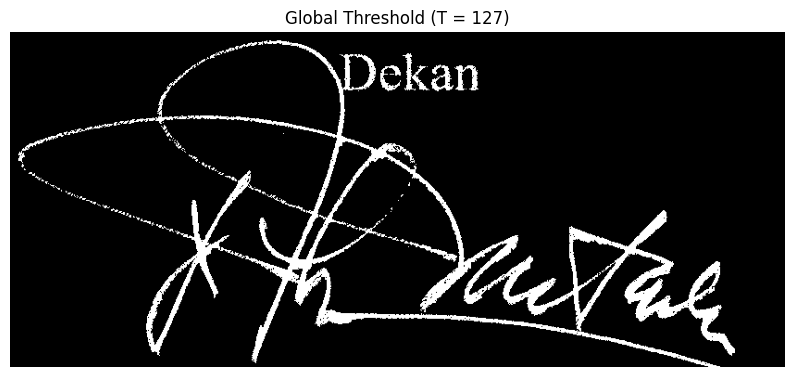

In [ ]:
# ==========================================
# GLOBAL THRESHOLD
# ==========================================

threshold_value = 127

_, thresh_global = cv2.threshold(
    gray,
    threshold_value,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(10, 5))
plt.imshow(thresh_global, cmap="gray")
plt.title(f"Global Threshold (T = {threshold_value})")
plt.axis("off")
plt.show()

Nilai threshold Otsu: 157.0


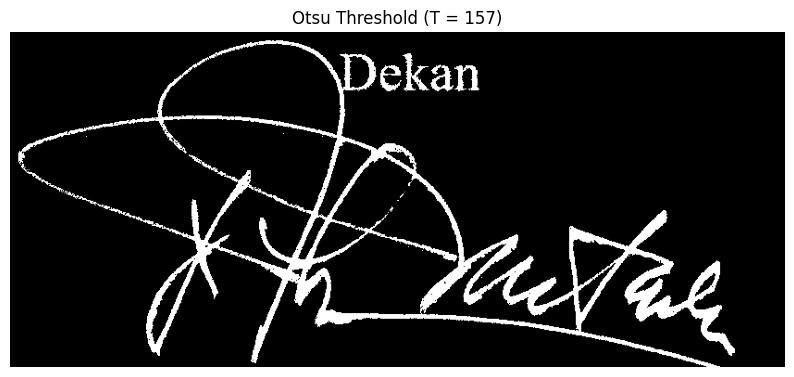

In [ ]:
# ==========================================
# OTSU THRESHOLD
# ==========================================

otsu_value, thresh_otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Nilai threshold Otsu:", otsu_value)

plt.figure(figsize=(10, 5))
plt.imshow(thresh_otsu, cmap="gray")
plt.title(f"Otsu Threshold (T = {otsu_value:.0f})")
plt.axis("off")
plt.show()

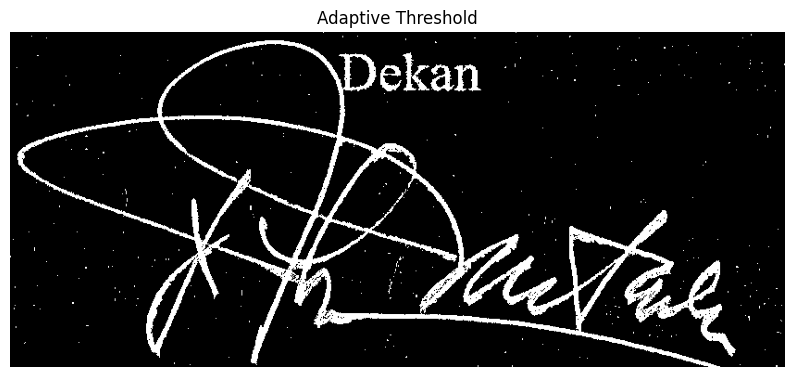

In [ ]:
# ==========================================
# ADAPTIVE THRESHOLD
# ==========================================

block_size = 31
C = 10

thresh_adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    block_size,
    C
)

plt.figure(figsize=(10, 5))
plt.imshow(thresh_adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

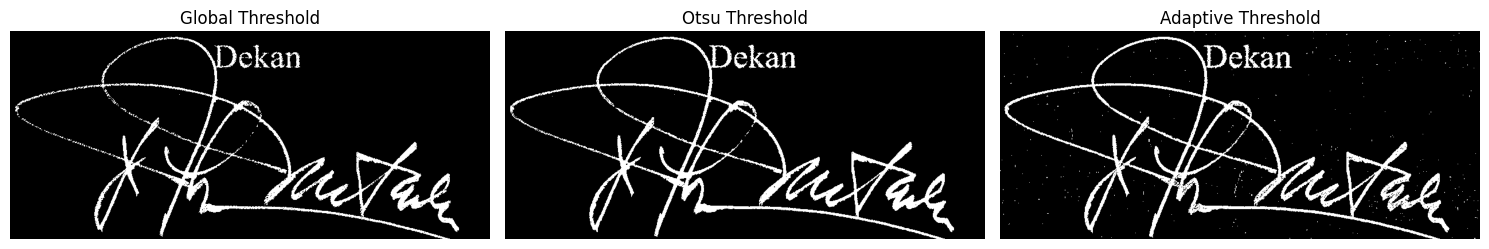

In [ ]:
# ==========================================
# PERBANDINGAN THRESHOLDING
# ==========================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresh_global, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(thresh_otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(thresh_adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# MORPHOLOGICAL OPERATION
# ==========================================

# Kernel morfologi
kernel = np.ones((3, 3), np.uint8)

def morphology_process(binary_image):
    # Opening
    opening = cv2.morphologyEx(
        binary_image,
        cv2.MORPH_OPEN,
        kernel
    )

    # Closing
    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    return opening, closing


# Proses masing-masing threshold
global_opening, global_morph = morphology_process(thresh_global)
otsu_opening, otsu_morph = morphology_process(thresh_otsu)
adaptive_opening, adaptive_morph = morphology_process(thresh_adaptive)

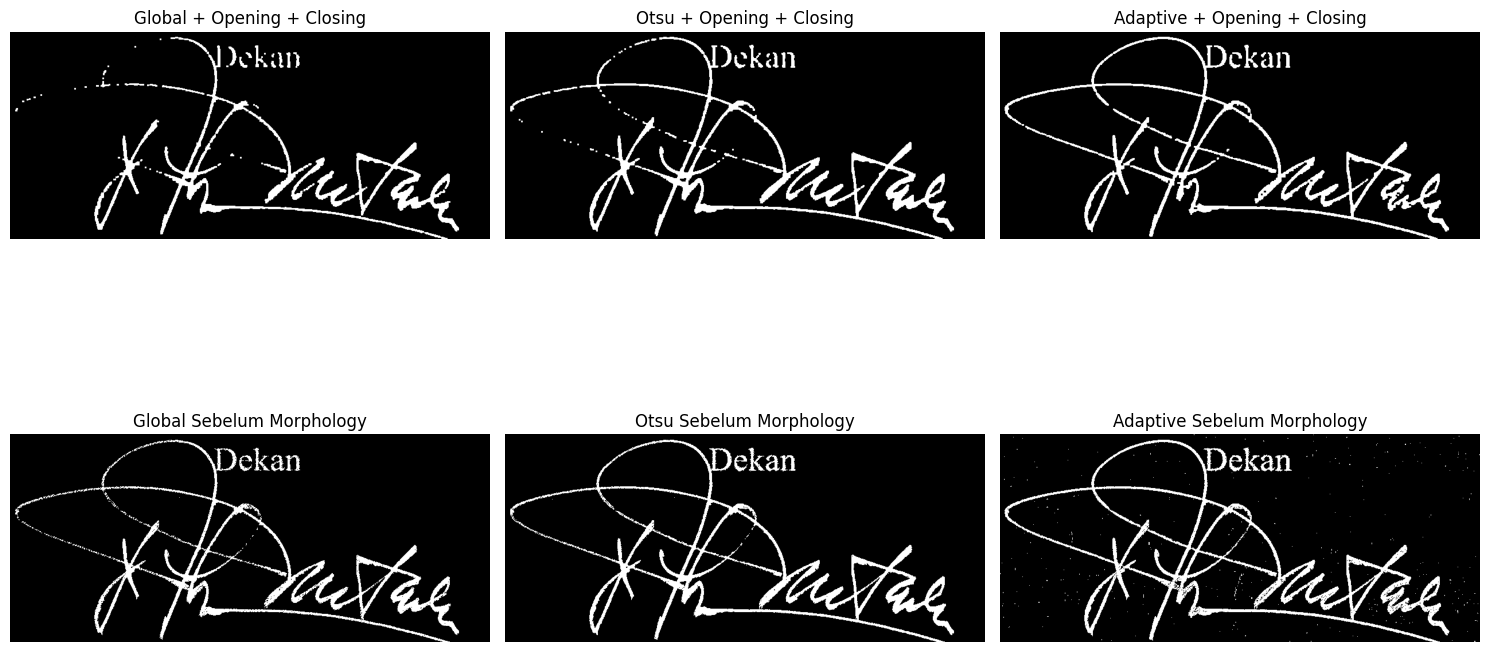

In [ ]:
# ==========================================
# HASIL MORPHOLOGY
# ==========================================

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(global_morph, cmap="gray")
plt.title("Global + Opening + Closing")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(otsu_morph, cmap="gray")
plt.title("Otsu + Opening + Closing")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(adaptive_morph, cmap="gray")
plt.title("Adaptive + Opening + Closing")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(thresh_global, cmap="gray")
plt.title("Global Sebelum Morphology")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(thresh_otsu, cmap="gray")
plt.title("Otsu Sebelum Morphology")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(thresh_adaptive, cmap="gray")
plt.title("Adaptive Sebelum Morphology")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# FOREGROUND PIXEL
# ==========================================

def calculate_foreground(binary_image):
    foreground_pixels = np.sum(binary_image == 255)
    total_pixels = binary_image.size
    foreground_ratio = foreground_pixels / total_pixels

    return foreground_pixels, total_pixels, foreground_ratio


# Hitung untuk setiap metode
global_fg, total_pixels, global_ratio = calculate_foreground(global_morph)
otsu_fg, _, otsu_ratio = calculate_foreground(otsu_morph)
adaptive_fg, _, adaptive_ratio = calculate_foreground(adaptive_morph)


print("====================================")
print("HASIL FOREGROUND PIXEL")
print("====================================")

print(f"Total piksel ROI      : {total_pixels:,}")
print()
print(f"Global foreground     : {global_fg:,}")
print(f"Global foreground %   : {global_ratio * 100:.2f}%")
print()
print(f"Otsu foreground       : {otsu_fg:,}")
print(f"Otsu foreground %     : {otsu_ratio * 100:.2f}%")
print()
print(f"Adaptive foreground   : {adaptive_fg:,}")
print(f"Adaptive foreground % : {adaptive_ratio * 100:.2f}%")

HASIL FOREGROUND PIXEL
Total piksel ROI      : 302,994

Global foreground     : 20,782
Global foreground %   : 6.86%

Otsu foreground       : 24,796
Otsu foreground %     : 8.18%

Adaptive foreground   : 25,887
Adaptive foreground % : 8.54%


In [ ]:
import pandas as pd

hasil_threshold = pd.DataFrame({
    "Metode": [
        "Global",
        "Otsu",
        "Adaptive"
    ],
    "Foreground Pixel": [
        global_fg,
        otsu_fg,
        adaptive_fg
    ],
    "Total Pixel": [
        total_pixels,
        total_pixels,
        total_pixels
    ],
    "Foreground (%)": [
        global_ratio * 100,
        otsu_ratio * 100,
        adaptive_ratio * 100
    ]
})

hasil_threshold

,Metode,Foreground Pixel,Total Pixel,Foreground (%)
0,Global,20782,302994,6.858882
1,Otsu,24796,302994,8.183660
2,Adaptive,25887,302994,8.543734


In [ ]:
# ==========================================
# SIGNATURE DETECTION
# ==========================================

decision_threshold = 2.0  # dalam persen

if otsu_ratio * 100 >= decision_threshold:
    hasil = "SIGNATURE PRESENT"
else:
    hasil = "SIGNATURE ABSENT"

print("====================================")
print("HASIL DETEKSI TANDA TANGAN")
print("====================================")
print(f"Foreground Otsu : {otsu_ratio * 100:.2f}%")
print(f"Batas keputusan : {decision_threshold:.2f}%")
print(f"HASIL           : {hasil}")

HASIL DETEKSI TANDA TANGAN
Foreground Otsu : 8.18%
Batas keputusan : 2.00%
HASIL           : SIGNATURE PRESENT


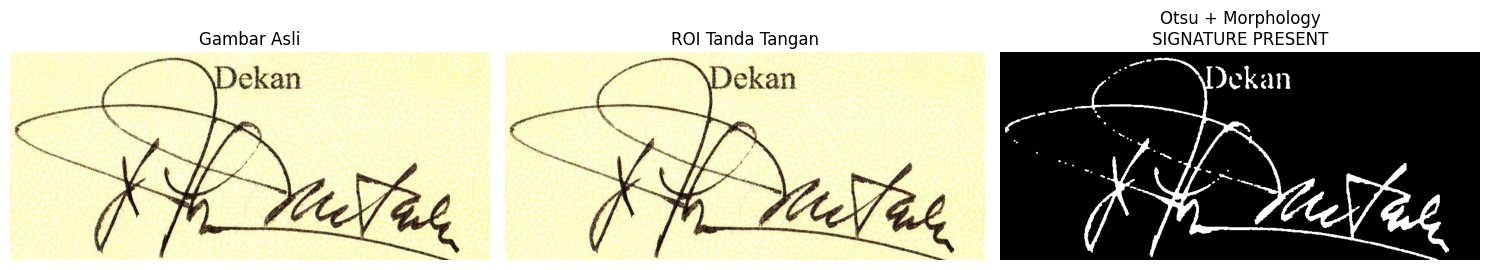

HASIL SISTEM
File                 : 01_HighQuality_Enhanced_CROP2.jpg
Metode               : Otsu
Foreground Pixel     : 24796
Foreground Percentage: 8.18%
Decision Threshold   : 2.00%
Decision             : SIGNATURE PRESENT


In [ ]:
# ==========================================
# HASIL AKHIR
# ==========================================

plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(roi_rgb)
plt.title("ROI Tanda Tangan")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(otsu_morph, cmap="gray")
plt.title(f"Otsu + Morphology\n{hasil}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("====================================")
print("HASIL SISTEM")
print("====================================")
print("File                 :", nama_file)
print("Metode               : Otsu")
print("Foreground Pixel     :", otsu_fg)
print("Foreground Percentage:", f"{otsu_ratio * 100:.2f}%")
print("Decision Threshold   :", f"{decision_threshold:.2f}%")
print("Decision             :", hasil)